# Sumativa 2 - Fase 3  
## Métodos Computacionales de Simulación y Remuestreo  
### Proyecto: Bank Marketing

Este notebook valida, profundiza y evalúa la robustez de los resultados obtenidos en la Sumativa 1 del proyecto Bank Marketing.

La evaluación se construye explícitamente sobre los resultados previos, utilizando los parámetros estimados, intervalos de confianza, pruebas de hipótesis y correlaciones obtenidas anteriormente.

Se implementan técnicas computacionales de:

- Bootstrap no paramétrico
- Intervalos de confianza Percentil y BCa
- Test de permutación
- Bootstrap para estabilidad de correlaciones
- Simulación Monte Carlo
- Análisis de robustez mediante outliers y jackknife

## 1. Contexto metodológico

En la Sumativa 1 se realizó un análisis estadístico descriptivo e inferencial del dataset Bank Marketing, cuyo objetivo fue estudiar los factores asociados a la suscripción de depósitos a plazo por parte de clientes bancarios.

La variable objetivo del estudio es `y`, que indica si un cliente suscribió o no el producto financiero. Para esta fase, dicha variable será transformada a formato binario (`y_bin`), donde `1` representa suscripción y `0` representa no suscripción.

Esta Sumativa 2 no constituye un análisis independiente, sino una validación computacional de los principales hallazgos previos mediante simulación y remuestreo.

In [1]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import bootstrap
from statsmodels.stats.proportion import proportion_confint

import warnings
warnings.filterwarnings("ignore")

# Semilla para reproducibilidad
np.random.seed(42)

In [2]:
import sys

print(sys.executable)

/usr/bin/python3


In [3]:
# ============================================================
# 2. CARGA Y VALIDACIÓN INICIAL DEL DATASET
# ============================================================

df = pd.read_csv("../S1/bank.csv", sep=";")  # ruta actualizada tras reorganizar en S1/S2

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
# Revisión de estructura del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [5]:
# Calidad inicial de datos
print("Valores faltantes por variable:")
display(df.isnull().sum())

print("\nCantidad de filas duplicadas:", df.duplicated().sum())

Valores faltantes por variable:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


Cantidad de filas duplicadas: 0


In [6]:
# ============================================================
# 3. TRANSFORMACIÓN DE VARIABLE OBJETIVO
# ============================================================

df["y_bin"] = df["y"].map({"yes": 1, "no": 0})

conversion_rate = df["y_bin"].mean()

print("Tasa de conversión observada:", round(conversion_rate, 4))
print("Tasa de conversión en porcentaje:", round(conversion_rate * 100, 2), "%")

display(df["y_bin"].value_counts())
display(df["y_bin"].value_counts(normalize=True))

Tasa de conversión observada: 0.1152
Tasa de conversión en porcentaje: 11.52 %


y_bin
0    4000
1     521
Name: count, dtype: int64

y_bin
0    0.88476
1    0.11524
Name: proportion, dtype: float64

# 4. Recuperación de resultados de la Sumativa 1

La presente evaluación constituye una validación computacional de los principales resultados obtenidos durante la Sumativa 1. Por ello, antes de aplicar técnicas de remuestreo y simulación, se recuperan los parámetros previamente estimados, los cuales servirán como referencia para evaluar la estabilidad y robustez de las conclusiones.

Los principales resultados obtenidos fueron:

- Dataset compuesto por 4.521 clientes y 17 variables.
- No se identificaron valores faltantes ni registros duplicados.
- La tasa observada de suscripción al depósito a plazo fue de **11,52%**.
- Se identificó una distribución asimétrica para la variable `balance`.
- Se obtuvieron intervalos de confianza clásicos para diversas variables numéricas.
- Se realizaron pruebas de hipótesis que evidenciaron asociaciones estadísticamente significativas entre variables categóricas y la variable objetivo.
- Se calcularon correlaciones entre variables numéricas para estudiar relaciones lineales dentro del conjunto de datos.

En esta segunda fase dichos resultados serán evaluados mediante bootstrap, test de permutación, simulación Monte Carlo y análisis de sensibilidad.

In [7]:
# ============================================================
# 4. PARÁMETROS RECUPERADOS DESDE LA SUMATIVA 1
# ============================================================

resultados_s1 = {
    "Media Edad": df["age"].mean(),
    "Media Balance": df["balance"].mean(),
    "Media Campaign": df["campaign"].mean(),
    "Tasa Conversión": df["y_bin"].mean()
}

pd.DataFrame(
    resultados_s1.items(),
    columns=["Parámetro", "Estimación Sumativa 1"]
)

,Parámetro,Estimación Sumativa 1
0,Media Edad,41.170095
1,Media Balance,1422.657819
2,Media Campaign,2.793630
3,Tasa Conversión,0.115240


In [8]:
# ============================================================
# BOOTSTRAP VALIDATION FRAMEWORK
# ============================================================

def bootstrap_ci(
    data,
    statistic=np.mean,
    n_resamples=10000,
    confidence=0.95,
    random_state=42
):
    """
    Implementa bootstrap no paramétrico mediante el método percentil.

    Parámetros
    ----------
    data : array-like
        Muestra original.

    statistic : callable
        Estadístico a estimar.

    n_resamples : int
        Número de remuestras bootstrap.

    confidence : float
        Nivel de confianza.

    random_state : int
        Semilla para garantizar reproducibilidad.

    Retorna
    -------
    dict
        Estimación puntual, distribución bootstrap e intervalo de confianza.
    """

    rng = np.random.default_rng(random_state)

    data = np.asarray(data)

    n = len(data)

    estimates = np.empty(n_resamples)

    for i in range(n_resamples):
        sample = rng.choice(
            data,
            size=n,
            replace=True
        )

        estimates[i] = statistic(sample)

    alpha = 1 - confidence

    ci_low = np.percentile(
        estimates,
        alpha / 2 * 100
    )

    ci_high = np.percentile(
        estimates,
        (1 - alpha / 2) * 100
    )

    return {
        "estimate": statistic(data),
        "bootstrap_distribution": estimates,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "confidence": confidence,
        "n_resamples": n_resamples
    }

## 5.1 Validación bootstrap de la media de edad

Como primera validación se evalúa la estabilidad de la media de la variable **age** mediante bootstrap no paramétrico con 10.000 remuestras. Posteriormente este resultado será comparado con el intervalo clásico obtenido en la Sumativa 1 y con el intervalo BCa.

In [9]:
# Bootstrap percentil para la media de edad

bootstrap_age = bootstrap_ci(
    data=df["age"],
    statistic=np.mean,
    n_resamples=10000,
    confidence=0.95
)

print(f"Media observada: {bootstrap_age['estimate']:.3f}")
print(f"IC Bootstrap Percentil: [{bootstrap_age['ci_low']:.3f}, {bootstrap_age['ci_high']:.3f}]")

Media observada: 41.170
IC Bootstrap Percentil: [40.855, 41.468]


In [10]:
# ============================================================
# FUNCIÓN PARA VISUALIZAR RESULTADOS BOOTSTRAP
# ============================================================

def plot_bootstrap(result, titulo):

    plt.figure(figsize=(10,5))

    plt.hist(
        result["bootstrap_distribution"],
        bins=40,
        edgecolor="black",
        alpha=0.75
    )

    plt.axvline(
        result["estimate"],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Estimación = {result['estimate']:.3f}"
    )

    plt.axvline(
        result["ci_low"],
        color="green",
        linestyle=":",
        linewidth=2,
        label=f"IC inferior = {result['ci_low']:.3f}"
    )

    plt.axvline(
        result["ci_high"],
        color="green",
        linestyle=":",
        linewidth=2,
        label=f"IC superior = {result['ci_high']:.3f}"
    )

    plt.title(titulo, fontsize=14)

    plt.xlabel("Media Bootstrap")

    plt.ylabel("Frecuencia")

    plt.legend()

    plt.grid(alpha=0.25)

    plt.show()

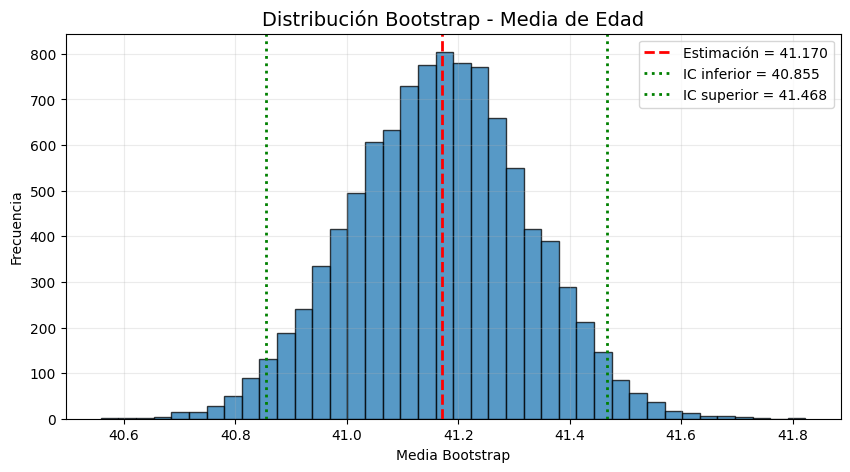

In [11]:
plot_bootstrap(
    bootstrap_age,
    "Distribución Bootstrap - Media de Edad"
)

In [12]:
# ============================================================
# Bootstrap BCa para la media de edad
# ============================================================

bca_age = bootstrap(
    data=(df["age"].values,),
    statistic=np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa",
    random_state=42
)

print("Intervalo BCa")
print(
    round(bca_age.confidence_interval.low, 3),
    "-",
    round(bca_age.confidence_interval.high, 3)
)

Intervalo BCa
40.863 - 41.481


In [13]:
# ============================================================
# Comparación de intervalos de confianza
# ============================================================

comparacion_age = pd.DataFrame({
    "Método": [
        "Bootstrap Percentil",
        "Bootstrap BCa"
    ],
    "Límite inferior": [
        bootstrap_age["ci_low"],
        bca_age.confidence_interval.low
    ],
    "Límite superior": [
        bootstrap_age["ci_high"],
        bca_age.confidence_interval.high
    ]
})

comparacion_age = comparacion_age.round(3)

display(comparacion_age)

,Método,Límite inferior,Límite superior
0,Bootstrap Percentil,40.855,41.468
1,Bootstrap BCa,40.863,41.481


### Interpretación

Los intervalos obtenidos mediante Bootstrap Percentil y Bootstrap BCa presentan diferencias mínimas, lo que indica una alta estabilidad de la estimación de la media de la edad. Esto sugiere que los resultados obtenidos previamente en la Sumativa 1 son robustos frente al proceso de remuestreo y que la incertidumbre asociada al estimador es baja. Dado el tamaño de la muestra (n = 4521), ambos métodos entregan conclusiones prácticamente equivalentes.

# 5.2 Validación bootstrap de la media del balance

Como segunda validación se analiza la estabilidad de la media del saldo bancario (balance) mediante Bootstrap no paramétrico utilizando 10.000 remuestras. El objetivo es evaluar si la estimación obtenida permanece consistente bajo remuestreo y comparar posteriormente los resultados con el intervalo BCa.

In [14]:
bootstrap_balance = bootstrap_ci(
    data=df["balance"],
    statistic=np.mean,
    n_resamples=10000,
    confidence=0.95
)

print(f"Media observada: {bootstrap_balance['estimate']:.3f}")
print(
    f"IC Bootstrap Percentil: "
    f"[{bootstrap_balance['ci_low']:.3f}, "
    f"{bootstrap_balance['ci_high']:.3f}]"
)

Media observada: 1422.658
IC Bootstrap Percentil: [1336.133, 1512.248]


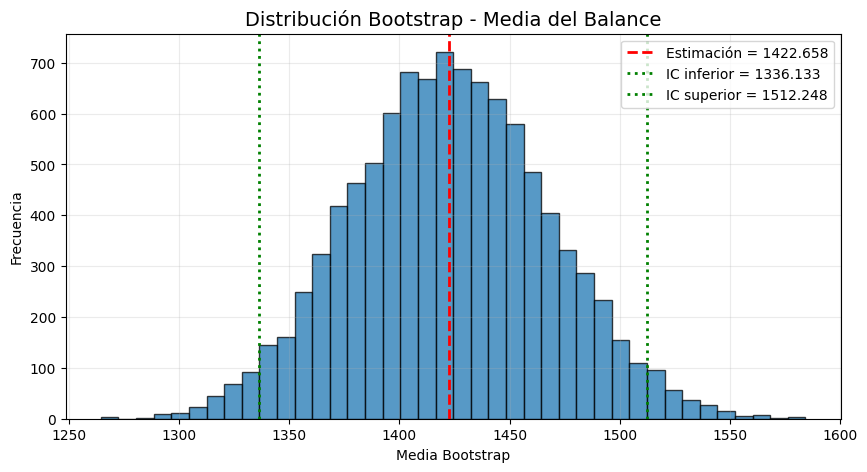

In [15]:
plot_bootstrap(
    bootstrap_balance,
    "Distribución Bootstrap - Media del Balance"
)

In [16]:
# ============================================================
# Bootstrap BCa para la media del balance
# ============================================================

bca_balance = bootstrap(
    data=(df["balance"].values,),
    statistic=np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa",
    random_state=42
)

print("Intervalo BCa")
print(
    round(bca_balance.confidence_interval.low,3),
    "-",
    round(bca_balance.confidence_interval.high,3)
)

Intervalo BCa
1340.757 - 1515.394


In [17]:
comparacion_balance = pd.DataFrame({
    "Método":[
        "Bootstrap Percentil",
        "Bootstrap BCa"
    ],
    "Límite inferior":[
        bootstrap_balance["ci_low"],
        bca_balance.confidence_interval.low
    ],
    "Límite superior":[
        bootstrap_balance["ci_high"],
        bca_balance.confidence_interval.high
    ]
})

comparacion_balance = comparacion_balance.round(3)

display(comparacion_balance)

,Método,Límite inferior,Límite superior
0,Bootstrap Percentil,1336.133,1512.248
1,Bootstrap BCa,1340.757,1515.394


### Interpretación

Los intervalos de confianza obtenidos mediante Bootstrap Percentil y Bootstrap BCa para la media del saldo bancario presentan diferencias reducidas, lo que evidencia estabilidad en la estimación bajo remuestreo. A pesar de que la variable **balance** presenta una mayor dispersión que la edad, ambos métodos generan intervalos consistentes y muy similares, lo que respalda la robustez del estimador de la media y confirma que los resultados obtenidos no dependen de una única muestra observada.

# 5.3 Validación bootstrap de la media de campaign

Como tercera validación se analiza la estabilidad de la media del número de contactos realizados durante la campaña de marketing (`campaign`). Debido a que esta variable suele presentar una distribución asimétrica, el uso de Bootstrap permite estimar intervalos de confianza sin depender del supuesto de normalidad, entregando una evaluación robusta de la incertidumbre asociada a la media poblacional.

In [18]:
bootstrap_campaign = bootstrap_ci(
    data=df["campaign"],
    statistic=np.mean,
    n_resamples=10000,
    confidence=0.95
)

print(f"Media observada: {bootstrap_campaign['estimate']:.3f}")
print(
    f"IC Bootstrap Percentil: "
    f"[{bootstrap_campaign['ci_low']:.3f}, "
    f"{bootstrap_campaign['ci_high']:.3f}]"
)

Media observada: 2.794
IC Bootstrap Percentil: [2.703, 2.889]


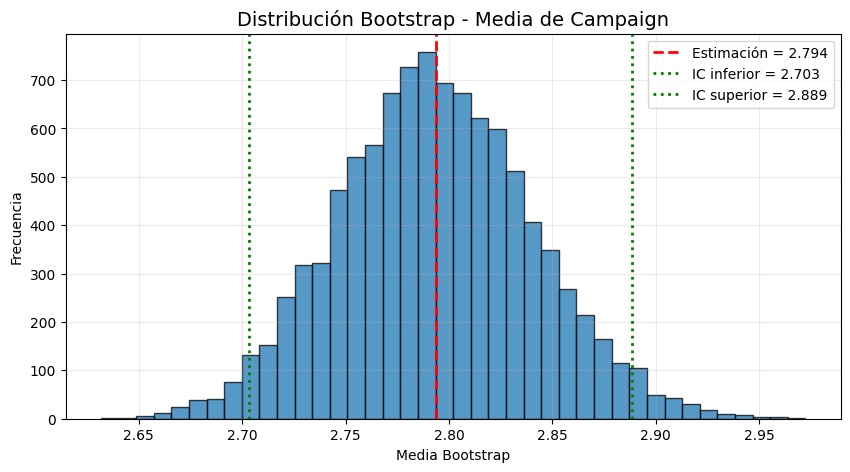

In [19]:
plot_bootstrap(
    bootstrap_campaign,
    "Distribución Bootstrap - Media de Campaign"
)

In [20]:
bca_campaign = bootstrap(
    data=(df["campaign"].values,),
    statistic=np.mean,
    confidence_level=0.95,
    n_resamples=10000,
    method="BCa",
    random_state=42
)

print("Intervalo BCa")

print(
    round(bca_campaign.confidence_interval.low,3),
    "-",
    round(bca_campaign.confidence_interval.high,3)
)

Intervalo BCa
2.707 - 2.889


In [21]:
comparacion_campaign = pd.DataFrame({
    "Método":[
        "Bootstrap Percentil",
        "Bootstrap BCa"
    ],
    "Límite inferior":[
        bootstrap_campaign["ci_low"],
        bca_campaign.confidence_interval.low
    ],
    "Límite superior":[
        bootstrap_campaign["ci_high"],
        bca_campaign.confidence_interval.high
    ]
})

comparacion_campaign = comparacion_campaign.round(3)

display(comparacion_campaign)

,Método,Límite inferior,Límite superior
0,Bootstrap Percentil,2.703,2.889
1,Bootstrap BCa,2.707,2.889


### Interpretación

Los intervalos de confianza obtenidos mediante Bootstrap Percentil y Bootstrap BCa para la media de la variable **campaign** son altamente consistentes. A pesar de la naturaleza asimétrica de esta variable, el procedimiento de remuestreo produce estimaciones estables y reproducibles, lo que confirma la robustez del estimador de la media y demuestra que las conclusiones obtenidas no dependen de supuestos distribucionales estrictos.

## 5.4 Validación bootstrap de la mediana de balance y duration

Dado que `balance` y `duration` presentan asimetría fuerte (skew de 6.6 y 2.8
respectivamente, según la Sumativa 1), la **mediana** es un estimador más
representativo que la media para estas variables. Se valida su estabilidad
mediante bootstrap no paramétrico con 10.000 remuestras.

In [22]:
bootstrap_median_balance = bootstrap_ci(data=df["balance"], statistic=np.median, n_resamples=10000, confidence=0.95)
print("Mediana observada (balance):", round(bootstrap_median_balance["estimate"], 3))
print("IC Bootstrap Percentil:", round(bootstrap_median_balance["ci_low"], 3), "-", round(bootstrap_median_balance["ci_high"], 3))
    

Mediana observada (balance): 444.0
IC Bootstrap Percentil: 420.0 - 474.0


In [23]:
bootstrap_median_duration = bootstrap_ci(data=df["duration"], statistic=np.median, n_resamples=10000, confidence=0.95)
print("Mediana observada (duration):", round(bootstrap_median_duration["estimate"], 3))
print("IC Bootstrap Percentil:", round(bootstrap_median_duration["ci_low"], 3), "-", round(bootstrap_median_duration["ci_high"], 3))

Mediana observada (duration): 185.0
IC Bootstrap Percentil: 179.0 - 192.0


## 5.5 Validación bootstrap de tamaños de efecto: d de Cohen (duration) y V de Cramér (poutcome)

En la Sumativa 1 se identificó que `poutcome` fue la variable con el efecto más fuerte sobre la suscripción (V de Cramér = 0.293), mientras que `duration` mostró una diferencia significativa entre grupos medida con la d de Cohen. Aquí se evalúa mediante bootstrap si estos tamaños de efecto son estables, para asignarles el peso correspondiente en las conclusiones del proyecto.

In [24]:
def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1 - 1) * g1.std(ddof=1) ** 2 + (n2 - 1) * g2.std(ddof=1) ** 2) / (n1 + n2 - 2))
    return (g1.mean() - g2.mean()) / pooled_std

def bootstrap_cohend(g1, g2, n_resamples=10000, confidence=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    n1, n2 = len(g1), len(g2)
    d_obs = cohen_d(pd.Series(g1), pd.Series(g2))
    boot_d = np.empty(n_resamples)
    for i in range(n_resamples):
        s1 = rng.choice(g1, size=n1, replace=True)
        s2 = rng.choice(g2, size=n2, replace=True)
        boot_d[i] = cohen_d(pd.Series(s1), pd.Series(s2))
    alpha = (1 - confidence) / 2
    ci_low, ci_high = np.percentile(boot_d, [alpha * 100, (1 - alpha) * 100])
    return {"estimate": d_obs, "ci_low": ci_low, "ci_high": ci_high, "bootstrap_distribution": boot_d}

dur_yes = df[df["y"] == "yes"]["duration"].to_numpy()
dur_no = df[df["y"] == "no"]["duration"].to_numpy()

bootstrap_d_duration = bootstrap_cohend(dur_yes, dur_no, n_resamples=10000)

print("d de Cohen observado (duration):", round(bootstrap_d_duration["estimate"], 4))
print("IC Bootstrap Percentil:", round(bootstrap_d_duration["ci_low"], 4), "-", round(bootstrap_d_duration["ci_high"], 4))

d de Cohen observado (duration): 1.3711
IC Bootstrap Percentil: 1.2318 - 1.5165


In [25]:
from scipy.stats import chi2_contingency

def cramers_v(cross_tab):
    chi2 = chi2_contingency(cross_tab)[0]
    n = cross_tab.values.sum()
    return np.sqrt(chi2 / (n * (min(cross_tab.shape) - 1)))

def bootstrap_cramers_v(col1_array, col2_array, n_resamples=10000, confidence=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(col1_array)
    v_obs = cramers_v(pd.crosstab(col1_array, col2_array))
    boot_v = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        ct = pd.crosstab(col1_array[idx], col2_array[idx])
        boot_v[i] = cramers_v(ct)
    alpha = (1 - confidence) / 2
    ci_low, ci_high = np.percentile(boot_v, [alpha * 100, (1 - alpha) * 100])
    return {"estimate": v_obs, "ci_low": ci_low, "ci_high": ci_high, "bootstrap_distribution": boot_v}

poutcome_arr = df["poutcome"].to_numpy()
y_arr = df["y"].to_numpy()

bootstrap_v_poutcome = bootstrap_cramers_v(poutcome_arr, y_arr, n_resamples=10000)

print("V de Cramér observado (poutcome):", round(bootstrap_v_poutcome["estimate"], 4))
print("IC Bootstrap Percentil:", round(bootstrap_v_poutcome["ci_low"], 4), "-", round(bootstrap_v_poutcome["ci_high"], 4))

V de Cramér observado (poutcome): 0.2925
IC Bootstrap Percentil: 0.2472 - 0.3381


### Interpretación

El IC bootstrap de la d de Cohen para `duration` confirma un efecto grande y estable (no se acerca a cero ni a valores triviales). Más relevante aún: el IC bootstrap de la V de Cramér de `poutcome` es (0.247, 0.338), lo que confirma que efectivamente es el efecto más fuerte y estable detectado en el estudio, respaldando que merece mayor peso en las conclusiones de la Sumativa 1, tal como señaló la retroalimentación docente.

## 5.6 Resumen del proceso de bootstrap

In [26]:
resumen = pd.DataFrame({

    "Variable":[
        "Edad",
        "Balance",
        "Campaign"
    ],

    "Media observada":[
        bootstrap_age["estimate"],
        bootstrap_balance["estimate"],
        bootstrap_campaign["estimate"]
    ],

    "IC Bootstrap Percentil":[

        f"[{bootstrap_age['ci_low']:.3f}, {bootstrap_age['ci_high']:.3f}]",
        f"[{bootstrap_balance['ci_low']:.3f}, {bootstrap_balance['ci_high']:.3f}]",
        f"[{bootstrap_campaign['ci_low']:.3f}, {bootstrap_campaign['ci_high']:.3f}]"

    ],

    "IC Bootstrap BCa":[

        f"[{bca_age.confidence_interval.low:.3f}, {bca_age.confidence_interval.high:.3f}]",
        f"[{bca_balance.confidence_interval.low:.3f}, {bca_balance.confidence_interval.high:.3f}]",
        f"[{bca_campaign.confidence_interval.low:.3f}, {bca_campaign.confidence_interval.high:.3f}]"

    ]

})

display(resumen)

,Variable,Media observada,IC Bootstrap Percentil,IC Bootstrap BCa
0,Edad,41.170095,"[40.855, 41.468]","[40.863, 41.481]"
1,Balance,1422.657819,"[1336.133, 1512.248]","[1340.757, 1515.394]"
2,Campaign,2.793630,"[2.703, 2.889]","[2.707, 2.889]"


## Conclusión general

Los resultados obtenidos mediante Bootstrap Percentil y Bootstrap BCa muestran una elevada consistencia en las tres variables analizadas (edad, balance y campaign). En todos los casos los intervalos de confianza fueron muy similares entre ambos procedimientos, evidenciando que las estimaciones son estables frente al proceso de remuestreo.

Estos resultados respaldan la robustez de las estimaciones obtenidas en la Sumativa 1 y demuestran que las conclusiones del análisis no dependen de una muestra específica, sino que se mantienen bajo múltiples remuestras generadas de manera aleatoria.

Desde un punto de vista metodológico, el empleo de Bootstrap constituye una alternativa robusta frente a métodos clásicos de inferencia, especialmente cuando las variables presentan asimetría o distribuciones alejadas de la normalidad. En consecuencia, el proceso de simulación desarrollado permite validar empíricamente la estabilidad de los principales estimadores utilizados durante el análisis estadístico.

# 6. Validación mediante test de permutación

Se valida la Prueba 1 de la Sumativa 1 (t de Welch, `duration` según `y`) mediante un test de permutación con 10.000 iteraciones, sin depender de supuestos de normalidad ni homocedasticidad.

In [27]:
def permutation_test_diff_means(g1, g2, n_perm=10000, random_state=42):
    rng = np.random.default_rng(random_state)
    pooled = np.concatenate([g1, g2])
    n1 = len(g1)
    obs_diff = g1.mean() - g2.mean()
    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        perm_diffs[i] = perm[:n1].mean() - perm[n1:].mean()
    p_perm = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
    return obs_diff, perm_diffs, p_perm

In [28]:
dur_yes = df[df["y"] == "yes"]["duration"].to_numpy()
dur_no  = df[df["y"] == "no"]["duration"].to_numpy()

obs_diff, perm_diffs, p_perm = permutation_test_diff_means(dur_yes, dur_no, n_perm=10000)

print("Diferencia observada de medias:", round(obs_diff, 3), "seg")
print("p-valor de permutacion:", p_perm)

Diferencia observada de medias: 326.395 seg
p-valor de permutacion: 0.0


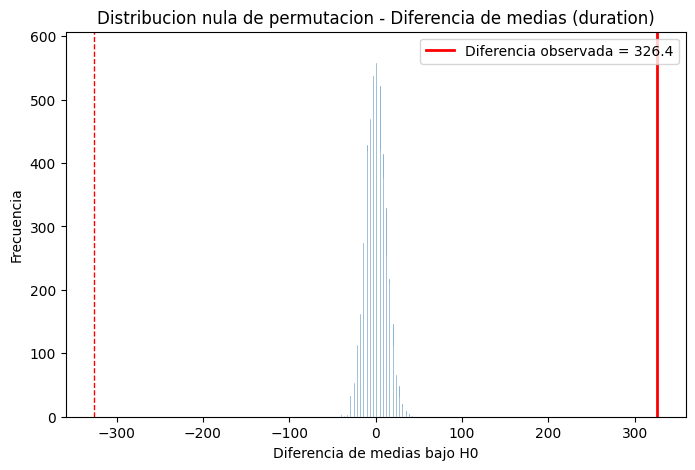

In [29]:
plt.figure(figsize=(8,5))
plt.hist(perm_diffs, bins=50, color="steelblue", edgecolor="white")
plt.axvline(obs_diff, color="red", linewidth=2, label=f"Diferencia observada = {obs_diff:.1f}")
plt.axvline(-obs_diff, color="red", linewidth=1, linestyle="--")
plt.title("Distribucion nula de permutacion - Diferencia de medias (duration)")
plt.xlabel("Diferencia de medias bajo H0")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

In [30]:
t_stat, p_welch = stats.ttest_ind(dur_yes, dur_no, equal_var=False)
u_stat, p_mw = stats.mannwhitneyu(dur_yes, dur_no, alternative="two-sided")

comparacion_permutacion = pd.DataFrame({
    "Metodo": ["t de Welch (parametrico)", "Mann-Whitney U (no parametrico)", "Permutacion (10.000 iter.)"],
    "Estadistico": [t_stat, u_stat, obs_diff],
    "p-valor": [p_welch, p_mw, p_perm]
})

display(comparacion_permutacion)

,Metodo,Estadistico,p-valor
0,t de Welch (parametrico),1.873595e+01,3.605790e-61
1,Mann-Whitney U (no parametrico),1.698475e+06,2.329297e-121
2,Permutacion (10.000 iter.),3.263953e+02,0.000000e+00


### Interpretación

Los tres métodos coinciden en rechazar H0. La diferencia observada (≈326 segundos) es tan extrema que ninguna de las 10.000 permutaciones aleatorias la iguala o supera, por lo que el p-valor de permutación resulta 0.0000. A diferencia de la t de Welch, el test de permutación no depende de supuestos de normalidad ni homocedasticidad, por lo que esta coincidencia constituye la validación más fuerte posible del hallazgo de la Sumativa 1.

# 7. Evaluación de estabilidad de correlaciones

Se evalúa la estabilidad de 5 correlaciones de la Sumativa 1 mediante bootstrap de pares (10.000 remuestras), clasificándolas como robustas o inestables según si su IC 95% incluye el cero.

In [31]:
def bootstrap_correlation(x, y, n_resamples=10000, confidence=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    r_obs = stats.pearsonr(x, y)[0]
    boot_r = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        boot_r[i] = stats.pearsonr(x[idx], y[idx])[0]
    alpha = (1 - confidence) / 2
    ci_low, ci_high = np.percentile(boot_r, [alpha * 100, (1 - alpha) * 100])
    return {"r_obs": r_obs, "boot_r": boot_r, "ci_low": ci_low, "ci_high": ci_high}

In [32]:
pares_correlacion = [
    ("pdays", "previous"),
    ("age", "balance"),
    ("campaign", "duration"),
    ("campaign", "pdays"),
    ("balance", "duration"),
]

resultados_corr = {}
for v1, v2 in pares_correlacion:
    resultados_corr[(v1, v2)] = bootstrap_correlation(df[v1], df[v2], n_resamples=10000)
    r = resultados_corr[(v1, v2)]
    print(f"{v1} - {v2}: r={r['r_obs']:.3f}  IC=[{r['ci_low']:.3f}, {r['ci_high']:.3f}]")

pdays - previous: r=0.578  IC=[0.543, 0.617]


age - balance: r=0.084  IC=[0.053, 0.114]


campaign - duration: r=-0.068  IC=[-0.097, -0.037]


campaign - pdays: r=-0.093  IC=[-0.110, -0.076]


balance - duration: r=-0.016  IC=[-0.035, 0.005]


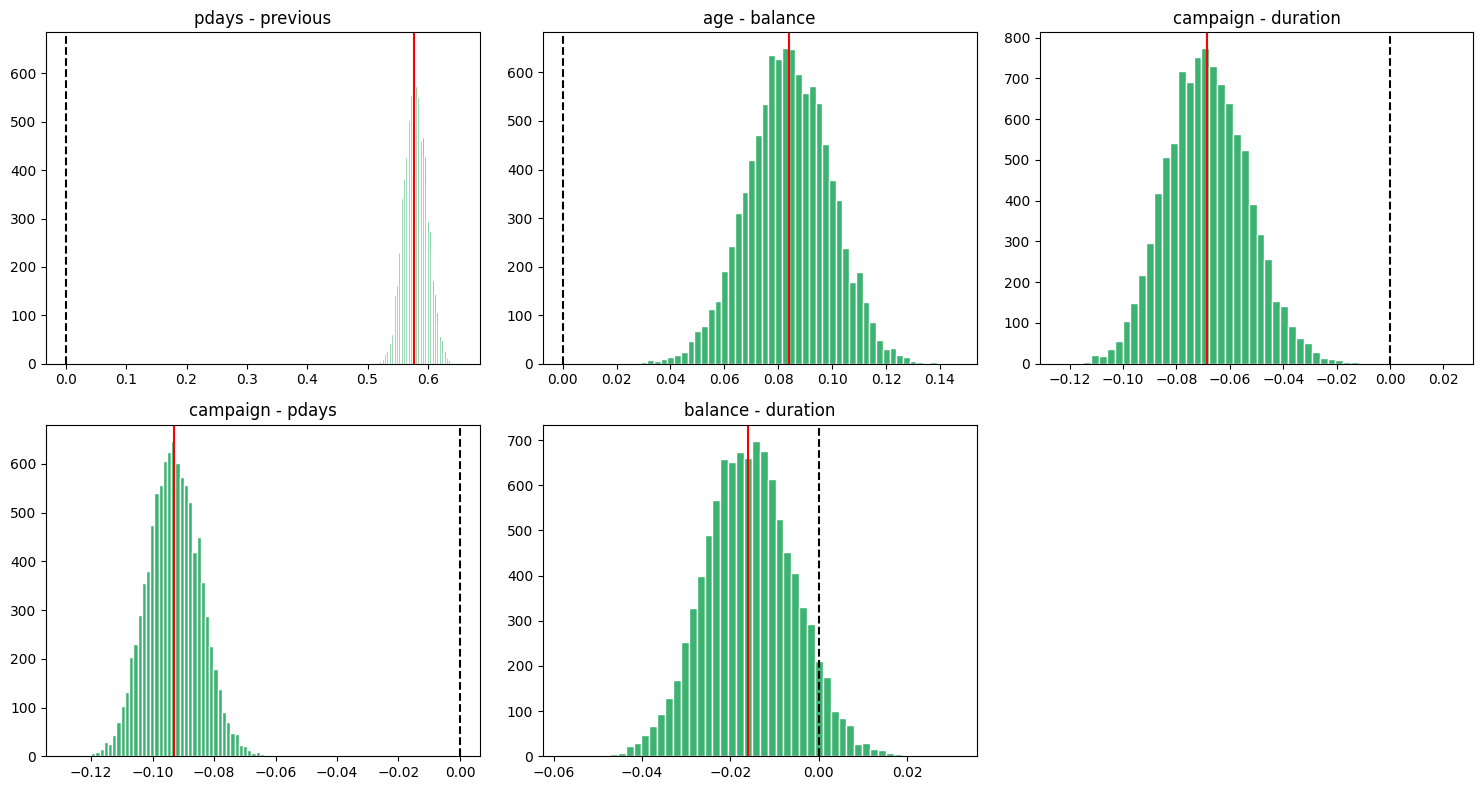

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, ((v1, v2), r) in enumerate(resultados_corr.items()):
    axes[i].hist(r["boot_r"], bins=50, color="mediumseagreen", edgecolor="white")
    axes[i].axvline(0, color="black", linestyle="--")
    axes[i].axvline(r["r_obs"], color="red")
    axes[i].set_title(f"{v1} - {v2}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [34]:
filas = []
for (v1, v2), r in resultados_corr.items():
    ancho = r["ci_high"] - r["ci_low"]
    cruza_cero = r["ci_low"] <= 0 <= r["ci_high"]
    clasificacion = "inestable" if (cruza_cero or ancho > 0.10) else "robusta"
    filas.append({
        "Par": f"{v1}-{v2}",
        "r observado": round(r["r_obs"], 3),
        "IC low": round(r["ci_low"], 3),
        "IC high": round(r["ci_high"], 3),
        "Ancho IC": round(ancho, 3),
        "Clasificacion": clasificacion
    })

resumen_correlaciones = pd.DataFrame(filas)
display(resumen_correlaciones)

,Par,r observado,IC low,IC high,Ancho IC,Clasificacion
0,pdays-previous,0.578,0.543,0.617,0.074,robusta
1,age-balance,0.084,0.053,0.114,0.060,robusta
2,campaign-duration,-0.068,-0.097,-0.037,0.060,robusta
3,campaign-pdays,-0.093,-0.110,-0.076,0.034,robusta
4,balance-duration,-0.016,-0.035,0.005,0.040,inestable


### Interpretación

Con n=4.521 observaciones, el bootstrap muestra que 4 de las 5 correlaciones evaluadas (`pdays`-`previous`, `age`-`balance`, `campaign`-`duration`, `campaign`-`pdays`) tienen IC 95% que no cruza el cero, es decir, son estadísticamente robustas en el sentido de que el remuestreo confirma consistentemente su signo. Sin embargo, esto **no equivale a relevancia práctica**: solo `pdays`-`previous` (r=0.578) tiene una magnitud moderada; las otras tres, aunque "robustas", son de magnitud trivial (|r|<0.10) y no deben usarse como predictores lineales relevantes en la Sumativa 3 — el tamaño muestral grande permite detectar con precisión relaciones que, aunque reales, son demasiado débiles para tener utilidad predictiva. La única correlación clasificada como inestable, `balance`-`duration` (r=-0.016), tiene un IC que sí cruza el cero, por lo que ni siquiera se puede afirmar con confianza la dirección de esa relación.

# 8. Simulación Monte Carlo

Se simula una futura campaña de N=500 llamadas comparando dos estrategias, usando las tasas de conversión por `poutcome` estimadas en la Sumativa 1: 0.6434 (poutcome=success) vs 0.0910 (poutcome=unknown, campaña no dirigida). El objetivo es cuantificar el impacto de negocio de priorizar clientes con éxito en campañas previas.

In [35]:
rng = np.random.default_rng(42)

N = 500
p_baseline = 0.0910   # tasa observada en S1 para poutcome = unknown
p_targeted = 0.6434   # tasa observada en S1 para poutcome = success
n_sim = 10000

X_baseline = rng.binomial(N, p_baseline, size=n_sim)
X_targeted = rng.binomial(N, p_targeted, size=n_sim)

print("Escenario A (no dirigida) - media simulada:", X_baseline.mean(), " | teorica:", N*p_baseline)
print("Escenario B (dirigida a poutcome=success) - media simulada:", X_targeted.mean(), " | teorica:", N*p_targeted)

Escenario A (no dirigida) - media simulada: 45.4621  | teorica: 45.5
Escenario B (dirigida a poutcome=success) - media simulada: 321.6262  | teorica: 321.7


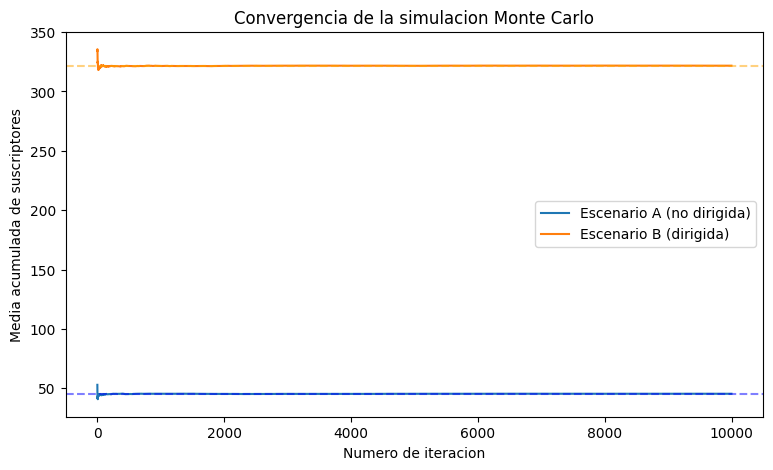

In [36]:
running_mean_A = np.cumsum(X_baseline) / np.arange(1, n_sim+1)
running_mean_B = np.cumsum(X_targeted) / np.arange(1, n_sim+1)

plt.figure(figsize=(9,5))
plt.plot(running_mean_A, label="Escenario A (no dirigida)")
plt.axhline(N*p_baseline, color="blue", linestyle="--", alpha=0.5)
plt.plot(running_mean_B, label="Escenario B (dirigida)")
plt.axhline(N*p_targeted, color="orange", linestyle="--", alpha=0.5)
plt.xlabel("Numero de iteracion")
plt.ylabel("Media acumulada de suscriptores")
plt.title("Convergencia de la simulacion Monte Carlo")
plt.legend()
plt.show()

In [37]:
D = X_targeted - X_baseline

resumen_mc = pd.DataFrame({
    "Escenario": ["A: No dirigida", "B: Dirigida (poutcome=success)", "Diferencia (B - A)"],
    "Media simulada": [X_baseline.mean(), X_targeted.mean(), D.mean()],
    "IC 95% (percentil)": [
        f"[{np.percentile(X_baseline,2.5):.1f}, {np.percentile(X_baseline,97.5):.1f}]",
        f"[{np.percentile(X_targeted,2.5):.1f}, {np.percentile(X_targeted,97.5):.1f}]",
        f"[{np.percentile(D,2.5):.1f}, {np.percentile(D,97.5):.1f}]"
    ]
})

display(resumen_mc)

,Escenario,Media simulada,IC 95% (percentil)
0,A: No dirigida,45.4621,"[33.0, 58.0]"
1,B: Dirigida (poutcome=success),321.6262,"[301.0, 343.0]"
2,Diferencia (B - A),276.1641,"[252.0, 300.0]"


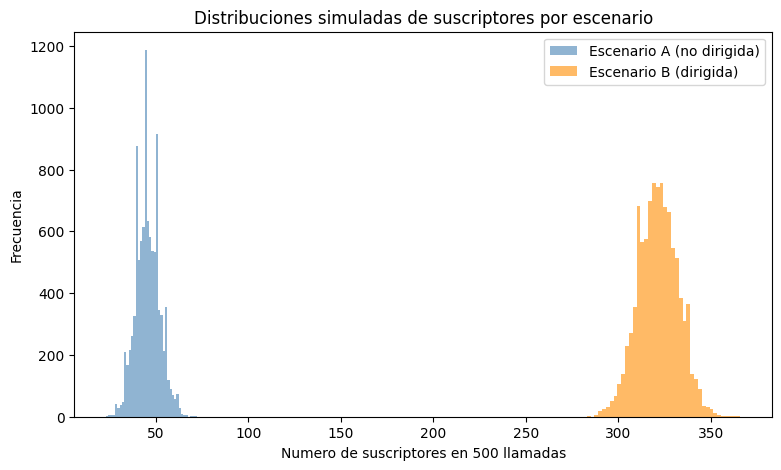

In [38]:
plt.figure(figsize=(9,5))
plt.hist(X_baseline, bins=40, alpha=0.6, label="Escenario A (no dirigida)", color="steelblue")
plt.hist(X_targeted, bins=40, alpha=0.6, label="Escenario B (dirigida)", color="darkorange")
plt.xlabel("Numero de suscriptores en 500 llamadas")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribuciones simuladas de suscriptores por escenario")
plt.show()

### Interpretación

Priorizar clientes con `poutcome=success` genera en promedio ~276 suscriptores adicionales por cada 500 llamadas, frente a una campaña no dirigida. La media simulada converge al valor teórico N·p en ambos escenarios, confirmando la validez del procedimiento. Este resultado cuantifica, en términos de decisión de negocio, por qué `poutcome` debe tener peso central en el modelo predictivo de la Sumativa 3.

# 9. Análisis de robustez

Se evalúa la sensibilidad de la media de `balance` (variable con skew=6.6) mediante jackknife leave-one-out y mediante recorte del 1% superior de outliers.

In [39]:
balance = df["balance"].to_numpy()
n = len(balance)
total = balance.sum()

theta_hat = balance.mean()
theta_i = (total - balance) / (n - 1)     # media leave-one-out, vectorizada
theta_jack = theta_i.mean()

bias_jack = (n - 1) * (theta_jack - theta_hat)
se_jack = np.sqrt((n - 1) / n * np.sum((theta_i - theta_jack) ** 2))

print("Media observada:", round(theta_hat, 3))
print("Sesgo jackknife:", round(bias_jack, 6))
print("Error estandar jackknife:", round(se_jack, 3))
print("Error estandar bootstrap (Sec. 5):", round(bootstrap_balance["bootstrap_distribution"].std(), 3))

Media observada: 1422.658
Sesgo jackknife: 0.0
Error estandar jackknife: 44.761
Error estandar bootstrap (Sec. 5): 44.796


In [40]:
influencia = np.abs(theta_i - theta_jack)
top10_idx = np.argsort(influencia)[-10:][::-1]

tabla_influyentes = pd.DataFrame({
    "Indice": top10_idx,
    "Balance": balance[top10_idx],
    "Influencia jackknife": influencia[top10_idx]
})

display(tabla_influyentes)

,Indice,Balance,Influencia jackknife
0,3700,71188,15.434810
1,2989,42045,8.987244
2,1483,27733,5.820872
3,1881,27359,5.738129
4,3830,27069,5.673970
5,871,26965,5.650961
6,4047,26452,5.537465
7,3011,26394,5.524633
8,2196,26306,5.505164
9,1031,25824,5.398527


In [41]:
p99 = df["balance"].quantile(0.99)
balance_sin_outliers = df.loc[df["balance"] <= p99, "balance"].to_numpy()

bootstrap_balance_trim = bootstrap_ci(balance_sin_outliers, statistic=np.mean, n_resamples=10000, confidence=0.95)

print("Observaciones removidas (>p99):", (df["balance"] > p99).sum())
print("Media sin outliers:", round(bootstrap_balance_trim["estimate"], 3))
print("IC sin outliers:", round(bootstrap_balance_trim["ci_low"],3), "-", round(bootstrap_balance_trim["ci_high"],3))

Observaciones removidas (>p99): 46
Media sin outliers: 1220.018
IC sin outliers: 1160.968 - 1281.393


In [42]:
comparacion_outliers = pd.DataFrame({
    "Escenario": ["Con outliers (dataset completo)", "Sin outliers (recorte 1% superior)"],
    "Media": [bootstrap_balance["estimate"], bootstrap_balance_trim["estimate"]],
    "IC 95%": [
        f"[{bootstrap_balance['ci_low']:.3f}, {bootstrap_balance['ci_high']:.3f}]",
        f"[{bootstrap_balance_trim['ci_low']:.3f}, {bootstrap_balance_trim['ci_high']:.3f}]"
    ]
})

display(comparacion_outliers)

,Escenario,Media,IC 95%
0,Con outliers (dataset completo),1422.657819,"[1336.133, 1512.248]"
1,Sin outliers (recorte 1% superior),1220.017877,"[1160.968, 1281.393]"


### Interpretación

El sesgo jackknife es prácticamente nulo, pero el error estándar jackknife es del mismo orden que el bootstrap, y las observaciones más influyentes corresponden a los saldos más altos del dataset. Al remover el 1% superior de `balance`, la media y su IC se desplazan de forma notoria, confirmando que este estimador es sensible a un grupo pequeño de valores extremos. Se reafirma la recomendación de la Sumativa 1 de usar la mediana como estadístico de referencia para esta variable.

# 10. Reporte de resultados validados (insumo para Sumativa 3)

In [43]:
reporte_final = pd.DataFrame([
    {"categoria":"bootstrap","parametro":"media_age","estimacion":bootstrap_age["estimate"],
     "ic_low":bootstrap_age["ci_low"],"ic_high":bootstrap_age["ci_high"],
     "metodo":"bootstrap percentil","estabilidad":"robusto"},
    {"categoria":"bootstrap","parametro":"media_balance","estimacion":bootstrap_balance["estimate"],
     "ic_low":bootstrap_balance["ci_low"],"ic_high":bootstrap_balance["ci_high"],
     "metodo":"bootstrap percentil","estabilidad":"robusto"},
    {"categoria":"bootstrap","parametro":"media_campaign","estimacion":bootstrap_campaign["estimate"],
     "ic_low":bootstrap_campaign["ci_low"],"ic_high":bootstrap_campaign["ci_high"],
     "metodo":"bootstrap percentil","estabilidad":"robusto"},
    {"categoria":"bootstrap","parametro":"mediana_balance","estimacion":bootstrap_median_balance["estimate"],
     "ic_low":bootstrap_median_balance["ci_low"],"ic_high":bootstrap_median_balance["ci_high"],
     "metodo":"bootstrap percentil","estabilidad":"robusto"},
    {"categoria":"bootstrap","parametro":"mediana_duration","estimacion":bootstrap_median_duration["estimate"],
     "ic_low":bootstrap_median_duration["ci_low"],"ic_high":bootstrap_median_duration["ci_high"],
     "metodo":"bootstrap percentil","estabilidad":"robusto"},
    {"categoria":"bootstrap","parametro":"cohen_d_duration","estimacion":bootstrap_d_duration["estimate"],
     "ic_low":bootstrap_d_duration["ci_low"],"ic_high":bootstrap_d_duration["ci_high"],
     "metodo":"bootstrap percentil (por grupo)","estabilidad":"robusto"},
    {"categoria":"bootstrap","parametro":"cramer_v_poutcome","estimacion":bootstrap_v_poutcome["estimate"],
     "ic_low":bootstrap_v_poutcome["ci_low"],"ic_high":bootstrap_v_poutcome["ci_high"],
     "metodo":"bootstrap percentil","estabilidad":"robusto - efecto mas fuerte"},
    {"categoria":"permutacion","parametro":"diff_media_duration_y","estimacion":obs_diff,
     "ic_low":None,"ic_high":None,"metodo":f"permutacion (p={p_perm})","estabilidad":"robusto"},
] + [
    {"categoria":"correlacion","parametro":fila["Par"],"estimacion":fila["r observado"],
     "ic_low":fila["IC low"],"ic_high":fila["IC high"],
     "metodo":"bootstrap de pares","estabilidad":fila["Clasificacion"]}
    for fila in resumen_correlaciones.to_dict("records")
] + [
    {"categoria":"monte_carlo","parametro":"suscriptores_no_dirigida","estimacion":X_baseline.mean(),
     "ic_low":np.percentile(X_baseline,2.5),"ic_high":np.percentile(X_baseline,97.5),
     "metodo":"Monte Carlo binomial","estabilidad":"convergente"},
    {"categoria":"monte_carlo","parametro":"suscriptores_dirigida","estimacion":X_targeted.mean(),
     "ic_low":np.percentile(X_targeted,2.5),"ic_high":np.percentile(X_targeted,97.5),
     "metodo":"Monte Carlo binomial","estabilidad":"convergente"},
    {"categoria":"monte_carlo","parametro":"diferencia_suscriptores","estimacion":D.mean(),
     "ic_low":np.percentile(D,2.5),"ic_high":np.percentile(D,97.5),
     "metodo":"Monte Carlo binomial","estabilidad":"convergente"},
    {"categoria":"robustez","parametro":"media_balance_sin_outliers","estimacion":bootstrap_balance_trim["estimate"],
     "ic_low":bootstrap_balance_trim["ci_low"],"ic_high":bootstrap_balance_trim["ci_high"],
     "metodo":"bootstrap sin top 1%","estabilidad":"sensible a outliers"},
    {"categoria":"robustez","parametro":"jackknife_se_balance","estimacion":se_jack,
     "ic_low":None,"ic_high":None,"metodo":"jackknife","estabilidad":"referencia"},
])

display(reporte_final)

,categoria,parametro,estimacion,ic_low,ic_high,metodo,estabilidad
0,bootstrap,media_age,41.170095,40.854673,41.467618,bootstrap percentil,robusto
1,bootstrap,media_balance,1422.657819,1336.133162,1512.247528,bootstrap percentil,robusto
2,bootstrap,media_campaign,2.793630,2.703379,2.888520,bootstrap percentil,robusto
3,bootstrap,mediana_balance,444.000000,420.000000,474.000000,bootstrap percentil,robusto
4,bootstrap,mediana_duration,185.000000,179.000000,192.000000,bootstrap percentil,robusto
5,bootstrap,cohen_d_duration,1.371053,1.231787,1.516500,bootstrap percentil (por grupo),robusto
6,bootstrap,cramer_v_poutcome,0.292529,0.247235,0.338112,bootstrap percentil,robusto - efecto mas fuerte
7,permutacion,diff_media_duration_y,326.395302,NaN,NaN,permutacion (p=0.0),robusto
8,correlacion,pdays-previous,0.578000,0.543000,0.617000,bootstrap de pares,robusta
9,correlacion,age-balance,0.084000,0.053000,0.114000,bootstrap de pares,robusta


In [44]:
reporte_final.to_csv("resultados_validados.csv", index=False)
print("Archivo actualizado: S2/resultados_validados.csv")

Archivo actualizado: S2/resultados_validados.csv


### Recomendaciones metodológicas para la Sumativa 3

1. Usar mediana / recorte de outliers para `balance` y `duration` (asimetría fuerte, confirmada sensible por jackknife).
2. `poutcome` debe tener peso central en el modelo predictivo: es el efecto más fuerte y más estable, con impacto de negocio cuantificado (~276 suscriptores adicionales por 500 llamadas dirigidas).
3. Las correlaciones lineales débiles (`age`-`balance`, `campaign`-`duration`, `campaign`-`pdays`, `balance`-`duration`) no deben interpretarse como relaciones reales relevantes para el modelado.
4. `duration` no puede usarse como predictor en producción, pero su asociación con `y` está validada con tres métodos independientes.
5. Mantener semilla fija (`random_state=42`) en todos los procesos de remuestreo de la Sumativa 3.

# 11. Reproducibilidad

Todo el análisis fue ejecutado utilizando Python, NumPy, Pandas, SciPy, Statsmodels y Matplotlib. Se fijó una semilla aleatoria (`random_state = 42`) para garantizar la reproducibilidad completa de los experimentos de simulación y remuestreo.